# Chapter 07. 딥러닝
- 딥러닝의 핵심 알고리즘인 인공 신경망을 배움
- 대표적인 인공 신경망 라이브러리인 케라스를 소개
- 인공 신경망 모델의 훈련을 돕는 도구를 소개

## 07-1 인공 신경망
- 러닝과 인공 신경망 알고리즘을 이해
- 케라스 프레임워크 내 예시 데이터를 통해 간단한 인공 신경망모델을 만들고자함

### MNIST 데이터셋
- 손으로 쓴 0〜9까지의 숫자로 이루어져 있음 
- MNIST와 크기, 개수가 동일하지만 숫자 대신 패션 아이템으로 이루어진 데이터임

#### TensorFlow 추가 내용
[TensorFlow](https://www.tensorflow.org)는 구글이 2015년 11월 오픈소스로 공개한 딥러닝 라이브러리

#### Keras 관련 추가 내용
- 케라스는 2015년 3월 프랑소와 숄레가 만든 딥러닝 라이브러리
- Keras를 사용하면 GPU를 사용할 수 있으며, GPU는 벡터와 행렬 연산에 매우 최적화되어 있기 때문에 곱셈과 덧셈이 많이 수행되는 인공 신경망
- 딥러닝 라이브러리 케라스(Keras)는 원래 여러 딥러닝 엔진(TensorFlow, Theano, CNTK 등)을 선택해서 사용할 수 있는 상위 레벨 API 였음
- 현재는 대부분 TensorFlow-Keras 형태로 사용되지만, 여전히 “백엔드”라는 개념이 남아 있으며, 현재 TensorFlow, [파이토치](https://pytorch.org/), [잭스](https://jax.readthedocs.io/) 사용 가능

In [77]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow" # 'torch', or 'jax'

import keras
import tensorflow as tf
keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()


print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.18.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##### 코드 설명
- `os.environ`은 파이썬에서 환경변수(Environment Variable)를 설정하는 기능을 제공
- 현재 `keras`가 어떤 백엔드를 사용할지 OS 환경 변수를 강제 설정했음
    - 🔍 Keras 백엔드란? \
    케라스(Keras)는 원래 여러 딥러닝 엔진(TensorFlow, Theano, CNTK 등)을 선택해서 사용할 수 있는 상위 레벨 API \
    현재는 대부분 TensorFlow-Keras 형태로 사용되지만, 여전히 "백엔드" 옵션 통해 엔진을 바꿀 수 있음

In [78]:
#GPU 가속 사용 여부 확인 코드
import time

# 큰 행렬 생성
a = tf.random.normal([5000, 5000])
b = tf.random.normal([5000, 5000])

start = time.time()
c = tf.matmul(a, b)
end = time.time()

print("연산 소요 시간:", end - start)
print("사용한 장치:", tf.test.gpu_device_name())

연산 소요 시간: 0.0023183822631835938
사용한 장치: /device:GPU:0


I0000 00:00:1763821137.774584   97597 gpu_device.cc:2022] Created device /device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


- 연산 속도가 CPU보다 훨씬 빠름 (보통 0.4~1초 정도)

### MNIST 데이터셋 import

In [79]:
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

In [80]:
# 학습 데이터, 테스트 데이터 크기 확인
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


![alt text](appendix/ch7/image.png)

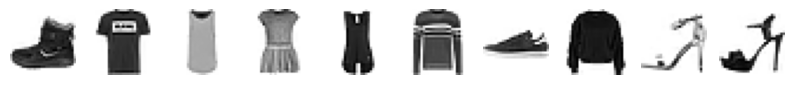

In [81]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()

- 크기가 28 x 28이다 보니 이미지가 흐릿함
- 6장에서 다루었던 것처럼 반전된 흑백 이미지
- 신발과 다양한 종류의 옷 데이터로 구성
- 처음 10개 샘플의 타깃값은 다음과 같음

In [82]:
print(train_target[:10])

[9 0 0 3 0 2 7 2 5 5]


- 각 레이블링 값 별 품목은 아래와 같음

![alt text](appendix/ch7/image-1.png)

- 레이블링 당 샘플 갯수를 한번 봅시다.
    -  0〜9까지 레이블마다 정확히 6,000개의 샘플 존재함을 확인

In [83]:
import numpy as np
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


### 로지스틱 회귀로 패션 아이템 분류모델
- 샘플은 60,000개나 되기 때문에 전체 데이터를 한꺼번에 사용하여 모델을 훈련이 어려울 것으로 판단됨 
- 샘플을 하나씩 꺼내서 모델을 훈련하는 방법이 더 효율적이라고 설명함
- 또한 해당 상황에서 확률적 경사 하강법을 사용하는 것이 더 효율적

- `SGDCIassifier` 클래스의 loss 매개변수를 `log_loss`로 지정하여 로지스틱 손실 함수를 최소화하는 확률적 경사 하강법 모델을 사용
- 먼저 6장에서 했듯이 `reshape()` 메서드를 사용해 2차원 배열인 각 샘플을 1차원 배열

#### 확률적 경사 하강법 복습
- 4장에서 SGDCIassifier를 사용할 때 **표준화 전처리된 데이터를 사용**했습니다. 
    - 확률적 경사 하강법은 여러 특성 중 기울기가 가장 가파른 방향을 따라 이동
    - 만약 특성마다 **값의 범위가 많이 다르면 올바르게 손실 함수의 경사를 내려올 수 없음** 
    - 패션 MNIST의 경우 **각 픽셀은 0〜255 사이의 정숫값**을 가집니다. 
    - 이런 이미지의 경우 보통 **255로 나누어 0〜1 사이의 값으로 정규화**합니다. 
    - 이는 표준화는 아니지만 양수 값으로 이루어진 이미지를 전처리할 때 널리 사용하는 방법임

In [84]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)

- `reshape()` 메서드의 두 번째 매개변수를 $28 \times 28 = 784$ 이미지 크기에 맞게 지정하면 첫 번째 차원 (샘플 개수)은 변하지 않고 원본 데이터의 두 번째, 세 번째 차원이 1차원으로 합쳐짐

In [85]:
print(train_scaled.shape)

(60000, 784)


- `SGDClassifier` 클래스와 `cross_validate` 함수를 사용해 이 데이터에서 교차 검증으로 성능을 확인

In [86]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1) 
print(np.mean(scores['test_score']))

/home/user/miniforge3/envs/mldl_practice/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/user/miniforge3/envs/mldl_practice/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/user/miniforge3/envs/mldl_practice/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/user/miniforge3/envs/mldl_practice/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasin

0.8194166666666666


- 90%까지 성능이 나오지 않음
- 로지스틱 공식을 지금 상황에 맞게 적용하면 아래와 같음
$$
z\_{티셔츠} = w_1 \times (픽셀1) + w_2 \times (픽셀2) + \dots + w_{784} \times (픽셀784) + b \\
z'\_{바지} = w_1' \times (픽셀1) + w_2' \times (픽셀2) + \dots + w_{784}' \times (픽셀784) + b' \\
\dots
$$
- 이렇게 총 10개 식이 나오며 그림으로 설명하면 아래와 같음

![alt text](appendix/ch7/image-2.png)

### 인공 신경망(ANN; Artificial Neural Network)
- 뉴런의 모양을 흉내낸 수학 모델
- 가장 기본적인 인공 신경망은 확률적 경사 하강법을 사용하는 로지스틱 회귀와 같음
- 상기에서 그림으로 설명한 내용을 참고

![alt text](appendix/ch7/image-3.png)

#### 용어정리
- 출력층 output layer : $z_1 \sim z_{10}$ 을 의미하며 $z$ 값들을 계산하고 이를 바탕으로 클래스를 예측하기 때문에 신경망의 최종 값을 만든다는 의미
- 뉴런 Neuron, 유닛 Unit : $z$ 값을 계산하는 단위
- 입력층 input layer : $x_1 \sim x_{784}$ 를 지칭, 입력 그 자체로 별다른 연산을 수행하지 않음 
- 가중치 : 각 feature 별로 곱해지는 값, 상기 식에서 $w$ 지칭
- 밀집층 dense layer, 완전 연결층 fully connected layer : 그림에서 왼쪽에 있는 784개의 픽셀과 오른쪽에 있는 10개의 뉴런이 연결된 선 갯수는 $784 \times 10 = 7,840$ 개의 연결된 선이 있어 밀집층이라고 이름 붙음

#### 딥러닝과 인공 신경망의 차이
- 딥러닝은 인공 신경망과 거의 동의어로 사용되는 경우가 많음
- 혹은 심층 신경망(deep neural network. DNN)을 딥러닝이라고 부르며 심충 신경망은 다음 절에서 보겠지만 여러 개의 층을 가진 인공 신경망을 말함

### ANN 모델 만들기
- 로지스틱 회귀에서 만든 훈련 데이터 `train_scaled`와 `train_target`을 사용
- 로지스틱 회귀에서는 교차 검증을 사용해 모델을 평가했지만, 인공 신경망에서는 교차 검증을 잘 사용하지 않고 검증 세트를 별도로 덜어내어 사용 \
    ① 딥러닝 분야의 데이터셋은 충분히 크기 때문에 검증 점수가 안정적이고, \
    ② 교차 검증을 수행하기에는 훈련시간이 너무 오래 걸리기 때문 

In [87]:
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [88]:
# 훈련세트 검증 세트 크기 비교 
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [89]:
inputs = keras.layers.Input(shape=(784,)) # shape 매개 견수는 튜플로 값을 받음

In [ ]:
dense = keras.layers.Dense(10, activation='softmax') 

NameError: name 'keras' is not defined

- 뉴런 갯수 10개 이고 뉴런 출력에 적용할 함수를 지정하는데 다중 분류이기에 softmax를 사용
- 2개의 클래스를 분류하는 이진 분류라면 시그모이드 함수를 사용하기 위해 `activation='sigmoid'`와 같이 설정

In [91]:
model = keras.Sequential([inputs, dense])

- `Sequential` 클래스의 객체를 만들 때 앞에서 만든 입력층 객체 inputs와 밀집층의 객체 dense를 리스트로 묶어 전달하여 신경망 모델 model 객체를 생성함

![현재 만들어진 객체 model의 상황](appendix/ch7/image-4.png)

-  활성화 함수 activation function : 소프트맥스와 같이 뉴런의 선형 방정식 계산 결과에 적용되는 함수

### 인공 신경망으로 패션 아이템 분류하기
- 케라스 모델은 훈련하기 전에 설정 단계가 있는데 이런 설정을 model 객체의 `compile()` 메서드에서 수행
- 손실 함수의 종류를 지정해야하며, 그 다음 훈련 과정에서 계산하고 싶은 측정값을 지정
- 케라스 모델에서 사용할 수 있는 손실 함수는 크게 2가지로 나뉨
    - 이진 분류: loss = ‘binary_crossentropy’
    - 다중 분류: loss = ‘categorical_crossentropy’

In [92]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#### `sparse_categorical_crossentropy`에 대한 고찰
- 케라스 모델에서 사용할 수 있는 손실 함수는 크게 2가지로 나뉨
    - 이진 분류: loss = ‘binary_crossentropy’
    - 다중 분류: loss = ‘categorical_crossentropy’

- sparse 부족한 이라는 뜻이 들어간 이유 
    - 레이블(참값) 데이터가 *원-핫 인코딩(one-hot encoding)* 되지 않은, 정수형(integer-encoded) 레이블이라는 점을 의미
    - 빽빽한 array 말고 정수값 하나만 써서 cross enthropy를 계산
        - *원-핫 인코딩(One-Hot Encoding)* : 머신러닝이나 자연어 처리에서 범주형 데이터(문자, 분류 등 순서가 없는 데이터)를 컴퓨터가 이해할 수 있는 숫자형 벡터로 변환하는 기법
        - 예: 타깃값을 해당 클래스만 1 이고 나머지는 모두 0인 배열로 만듦

 이진 크로스 엔트로피 손실을 위해 $-log$（예측 확률）에 타깃값（정답）을 곱함

 ![alt text](appendix/ch7/image-5.png)

- 이진 분류에서는 출력층의 뉴런이 하나로 이 뉴런이 출력하는 확률값 $\alpha$ (시그모이드 함수의 출력값)를 사용해 양성 클래스와 음성 클래스에 대한 크로스 엔트로피를 계산 (ch4의 로지스틱 손실 함수 참고)
- 이진 분류의 출력 뉴런은 오직 양성 클래스에 대한 확률 $\alpha$ 만 출력하기 때문에 음성 클래스에 대한 확률은 간단히 $1-\alpha$ 로 구할 수 있음

- 본래 이진 분류의 경우 타깃값을 $0$ 또는 $1$ 로 진행하는데, $0$ 을 곱해버리면 다 $0$ 이 되기 때문에 $1-타깃값$ 으로 변경하여 사용해 **하나의 뉴런으로 양성과 음성 클래스에 대한 크로스 엔트로피 손실을 모두 계산**

#### `compile()` 메서드의 두 번째 매개변수인 metrics에 대한 고찰
- 케라스는 모델은 훈련 할 때 기본적으로 에포크마다 손실 값을 출력
- 손실이 줄어드는 것을 보고 훈련이 잘되었다는 것을 알 수 있지만. `metrics` 매개변수에 리스트로 `['accuracy']`를 지정
- 하나의 지표를 지정할 때도 꼭 리스트로 전달해야 하며 여러 지표 지정도 가능

#### 다중 분류 계산법

![alt text](appendix/ch7/image-6.png)

- 출력층은 10개의 뉴런이 있고 10개의 클래스에 대한 확률을 출력
- 첫 번째 뉴런은 티셔츠일 확률이고 두 번째 뉴런은 바지일 확률로 뉴런들은 각각 레이블로 나뉠 확률을 가짐 
- 이진 분류와 달리 각 클래스에 대한 확률이 모두 출력되기 때문에 타깃에 해당하는 확률만 남겨 놓기 위해서 나머지 확률에는 모두 0을 곱함

In [93]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [94]:
model.fit(train_scaled, train_target, epochs=5)
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7370 - loss: 0.7853
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8346 - loss: 0.4845
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8452 - loss: 0.4564
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8504 - loss: 0.4425
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8537 - loss: 0.4337
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8462 - loss: 0.4364


[0.4444445073604584, 0.8458333611488342]

![alt text](appendix/ch7/image-18.png)

## 07-2 심층 신경망
- 층을 더 추가 할 수 있는데, 현재 모델에서 추가된 모델은 다음과 같음

![alt text](appendix/ch7/image-7.png)

- 은닉층 hidden layer: 입력층과 출력층 사이에 있는 모든 층입력층과 출력층 사이에 밀집층이 추가될 수 있는데, 
- 활성화 함수 : 신경망 층의 선형 방정식의 계산 값에 적용하는 함수

-  출력층에 적용하는 활성화 함수는 종류가 제한됨 
    - 이진 분류일 경우 시그모이드 함수
    - 다중 분류일 경우 소프트맥스 함수

- 클래스에 대한 확률을 출력하기 위해 출력층에 활성화 함수를 사용

#### 화귀를 위한 신경망의 출력층의 활성화 함수
- 회귀의 출력은 임의의 어떤 숫자이므로 활성화 함수를 적용할 필요가 없음
- 출력층 선형 방정식의 결과값을 그대로 출력하면 되기 때문
    - Dense층의 activation 매개변수에 아무런 값을 지정하지 않음 

#### 은닉층이라고 불리는 이유: 활성화 함수 적용 
- 은닉층이라 불리는 이유는 다른 값으로 대입되어 사라지기 때문

$$
(1)\ a \times 4 + 2 = b \\
(2)\ log(b) = k \\
(3)\ k \times 3 - 5 = c \\
\\
3log(a \times 4 + 2) - 5 = c
$$

- 인공 신경망을 그림으로 나타낼 때 활성화 함수를 생략하는 경우가 많은데 이는 절편과 마찬가지로 번거로움을 피하기 위해서 활성화 함수를 별개의 층으로 생각하지 않고 층에 포함되어 있다고 간주하는 경우가 많음 
- 그림에서 보이지는 않지만 모든 신경망의 은닉층에는 항상 활성화 함수가 존재

- 자주 쓰이는 활성화 함수는 Sigmoid 함수가 있음
$$
\phi = \frac{1}{1+e^{-z}}
$$

![alt text](appendix/ch7/image-8.png)

In [95]:
inputs = keras.layers.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='sigmoid')
dense2 = keras.layers.Dense(10, activation='softmax')

- dense1이 은닉층이고 100개의 뉴런을 가진 밀집층이고 sigmoid로 활성화 함수를 지정
- 은닉층의 뉴런 개수를 정하는 데는 특별한 기준이 없어 몇 개의 뉴런을 두어야 할지 판단하 
기 위해서는 상당한 경험이 필요
- 단, 적어도 출력층의 뉴런보다는 많게 만들어야 함
    - 클래스 10개에 대한 확률을 예측해야 하는데 이전 은닉층의 뉴런이 10개보다 적다면 부족한 정보가 전달 되기 때문 

### 심층 신경망(Deep Neural Network DNN) 만들기
- 앞에서 만든 inputs와 dense 1, dense2 객체를 Sequential 클래스에 추가하여 심층 신경망 객체 생성

![alt text](appendix/ch7/image-9.png)

In [96]:
model = keras.Sequential([inputs, dense1, dense2])
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

#### `model.summary()` 해석법
- 맨 첫 줄에 모델의 이름
- 그 다음 입력층을 제외하고 이 모델에 들어 있는 층이 순서대로 나열
    - 맨 처음 추가한 은닉층에서 출력층의 순서대로 나열
- 층마다 층 이름, 클래스, 출력 크기, 모델 파라미터 개수가 출력
    - 층을 만들 때 `name` 매개변수로 이름을 지정
    - 층 이름을 지정하지 않으면 케라스가 자동으로 'dense'라고 지칭(표의 Layer (type)부분을 참고)
    - 첫 번째 레이어 출력 크기를 보면 (None, 100)임
    - 첫 번째 차원은 샘플의 개수를 나타내고 (배치 차원이라고 지칭; 신경망 층에 입력되거나 출력)
    - 두 번째 차원은 은닉층의 뉴런 갯수를 지칭
    -  샘플 개수가 아직 정의되어 있지 않기 때문에 첫 번째 차원이 None 임
        - 케라스 모델의 `fit()`메서드에 훈련 데이터를 주입하면 이 데이터를 한 번에 모두 사용하지 않고 잘게 나누어 여러 번에 걸쳐 경사 하강법 단계를 수행; 미니배치 경사 하강법을 사용
        - 케라스의 기본 미니배치 크기는 32개로 이 값은 `fit()` 메서드에서 `batch_size` 매개변수로 바꿀 수 있음
        - 따라서 샘플 개수를 고정하지 않고 어떤 배치 크기에도 유연하게 대응할 수 있도록 None으로 설정
    - 샘플마다 784개의 픽셀값이 은닉층을 통과하면서 100개의 특성으로 압축됨
    - 모델 파라미터 개수가 출력되는데 이 층은 Dense 층이므로 입력 픽셀 784개와 100개의 모든 조합에 대한 가중치가 있음
    - 그리고 뉴런마다 1 개의 절편이 존재

    ![alt text](appendix/ch7/image-10.png)
    ![alt text](appendix/ch7/image-11.png)

    - 두 번째 층의 출력 크기는 (None, 10)으로 배치 차원은 동일하게 None이고 출력 뉴런 개수가 10개
    - 100개의 은닉층 뉴런과 10개의 출력충 뉴런이 모두 연결되고 출력충의 뉴런마다 하나의 절편이 있기 때문에 총 1,010개의 모델 파라미터 존재

- `summary()` 메서드의 마지막에는 총 모델 파라미터 개수와 훈련되는 파라미터 개수가 동일하게 79,510개로 나오는데, 은닉층과 출력층의 파라미터 개수를 합친 값임
- 그 아래 훈련되지 않는 파라미터 (Non-trainable params)는 0으로 나옴
    - 간혹 경사 하강법으로 훈련되지 않는 파라미터를 가진 층이 여기에 나옴


### 층을 추가하는 다른 방법

In [ ]:
## 세부적으로 이름을 명시
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='sigmoid', name='은닉층'),
    keras.layers.Dense(10, activation='softmax', name='출력층')
    ], name='패션 MNIST 모델')

In [98]:
model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 은닉층 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 출력층 (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
## add() 메서드를 통해 층을 추가
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(100, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [100]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7488 - loss: 0.7827
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8459 - loss: 0.4272
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8597 - loss: 0.3874
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8687 - loss: 0.3620
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8760 - loss: 0.3427


### 렐루(ReLU) 함수
- 시그모이드 함수의 경우 $\infty$ 혹은 $-\infty$ 로 갈 수록 그래프가 0, 1에 수렴하여 올바른 출력을 만드는데 느림
- 그래서 입력이 양수일 경우 활성화 함수가 없는 것 처럼 입력을 통과하고, 음수일 경우 0으로 만드는 ReLU 함수가 제안됨

![alt text](appendix/ch7/image-12.png)

-  이 함수는 $z$ 가 0보다 크면 $z$ 를 출력하고 $z$ 가 0보다 작으면 0을 출력

#### Flatten 클래스
- 배치 차원을 제외하고 나머지 입력 차원을 모두 일렬로 펼치는 역할만 함 
- 입력에 곱해지는 가중치나 절편이 없죠. 따라서 인공 신경망의 성능을 위해 기여하는 바는 없음 
- 하지만 Flatten 클래스를 층처럼 입력층과 은닉층 사이에 추가하기 때문에 이를 층이라고 부름

In [102]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28))) 
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [103]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

- 원본 이미지 크기인 (28,28), 즉 2차원으로 저장
    - Flatten 층이 1차원으로 펼쳐줌
- Flatten 층이 학습 하는 층으로 불리진 않기 때문에 깊이가 3인 신경망이라고 부르지 않음

In [104]:
# 1차원 데이터를 다시 원본 데이터로서 불러옴
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [105]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7616 - loss: 0.6778
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8520 - loss: 0.4078
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8667 - loss: 0.3637
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8781 - loss: 0.3366
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8860 - loss: 0.3188


- 시그모이드 활성화 함수 대비 0.8861 로 정확도가 향상

In [106]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8711 - loss: 0.3815


[0.3821093440055847, 0.8694166541099548]

### 하이퍼파라미터
1) 추가할 은닉층의 개수 
2) 뉴런 개수 
3) 활성화 함수 층의 종류 
4) `batch_size` 매개변수 
5) `epochs` 매개변수
6) `compile()`에서 사용할 경사 하강 알고리즘; 옵티마이저

    ![alt text](appendix/ch7/image-13.png)

- 기본 SGD 옵티마이저 사용 방법은 아래와 같음

```python
# SGD 사용 방법
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
```

- 학습률 변경시
```python
sgd = keras.optimizers.SGD(learning_rate=0.1)
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
```


- SGD 클래스의 `momentum` 매개변수의 기본값은 0인데, 이를 0보다 큰 값으로 지정하면 마치 이전의 그레이디 언트를 가속도처럼 사용하는 모멘텀 최적화amentum optimization 옵티마이저를 사용하게 됨 
    - 보통 모멘텀 매개변수는 0.9 이상을 지정

- SGD 클래스의 `nesterov` 매개변수를 기본값 False에서 True로 바꾸면 네스테로프 모멘텀 최적화nesterov momentum optimization (또는 네스테로프 가속 경사)를 사용
    - 네스테로프 모멘텀은 모멘텀 최적화를 2번 반복하여 구현

```python
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)
```

- 모델이 최적점에 가까이 갈수록 학습률을 낮출 수 있는데, 이렇게 하면 안정적으로 최적점에 수렴할 가능성이 높아짐 
- 이런 학습률을 적응적 학습률 adaptive learning rate이라고 하며 이런 방식들은 학습률 매개변수를 튜닝하는 수고를 덜 수 있는 것이 장점이 있음
    - `Adagrad`와 `RMSprop` 가 존재

```python
# Adagrad 예시
adagrad = keras.optimizers.Adagrad() # rmsprop = keras.optimizers.RMSprop() 후 optimizer 객체에 rmsprop 지정하면 RMSprop 옵티마이저 사용 가능
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
```

- 모멘텀 최적화와 RMSprop() 장점을 접목한 것이 Adam으로 Adam은 RMSprop과 함께 맨처음 시도해 볼 수 있는 좋은 알고리즘임 
- Adam 클래스도 keras.optimizers 패키지 아래에 아래에 있고, 적응적 학습률을 사용하는 이 3개의 클래스는 learning_rate 매개변수의 기본값으로 모두 0.001 을 사용

In [107]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [108]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7677 - loss: 0.6791
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8515 - loss: 0.4098
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8689 - loss: 0.3615
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8793 - loss: 0.3325
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8854 - loss: 0.3098


In [48]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.3311


[0.3329305350780487, 0.8820000290870667]

## 07-3 신경망 모델 훈련
- 인공 신경망 모델을 훈련하는 모범 사례와 필요한 도구들들을 살펴봄

- 머신러닝의 경우 모델의 구조가 어느 정도 고정이 되어 있어, 사이킷런에서 제공하는 
머신러닝 알고리즘들은 좋은 성능을 내기 위해 매개변수를 조정하고 훈련하는 과정을 반복
- 하지만 딥러닝은 층을 추가하고 층에 있는 뉴런의 개수와 활성화 함수를 결정하여 모델의 구조를 좀 더 직접적으로 만듦

### 손실 곡선
- Keras의 `fit()` 메서드는 History 클래스 객체를 반환
    - History 객체에는 훈련 과정에서 계산한 지표(손실과 정확도 값)가 저장

In [109]:
def model_fn(a_layer=None):
   model = keras.Sequential()
   model.add(keras.layers.Input(shape=(28,28)))
   model.add(keras.layers.Flatten())
   model.add(keras.layers.Dense(100, activation='relu'))
   if a_layer:
     model.add(a_layer)
   model.add(keras.layers.Dense(10, activation='softmax'))
   return model

-  if 구문의 역할은 `model_fn()`함수에 (a_layer 매개변수로) 케라스 층을 추가하면 은닉층 뒤에 또 하나의 층을 추 
가하는 것

In [110]:
model = model_fn()
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)

In [112]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


- 케라스는 기본적으로 에포크마다 손실을 계산 하는데, 정확도는 `compile()` 메서드에 metrics 매개변수에 'accuracy'를 추가했기 때문에 history 속성에 포함됨

- 에포크 마다 계산된 손실함수 결과, 정확도 값을 플롯으로 그려보면 다음과 같음
- 파이썬 리스트의 인덱스는 0부터 시작하므로 5개의 에포크가 0에서부터 4까지 x축에 표현되며 y축은 계산된 손실 값 혹은 정확도 값임

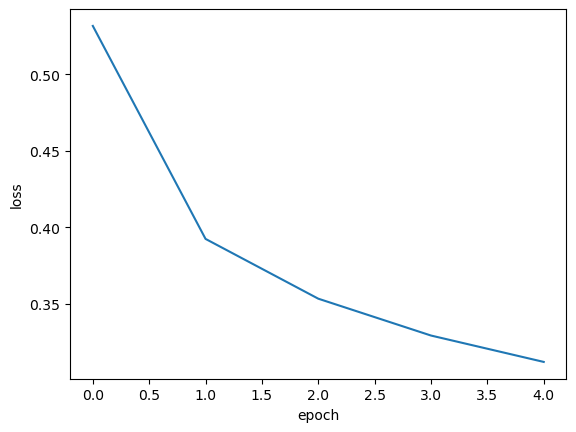

In [113]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()


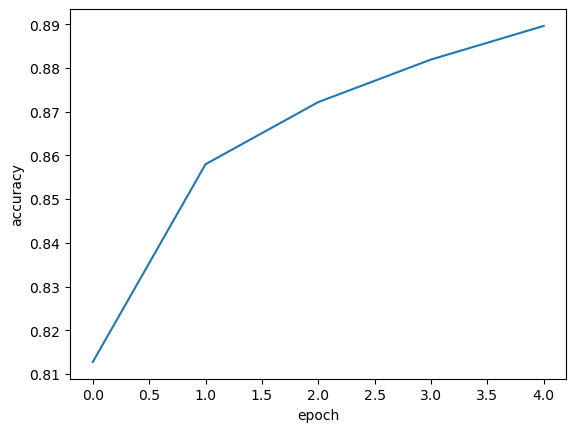

In [114]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

- 에포크 횟수를 늘려서 진행한 결과는 다음과 같음

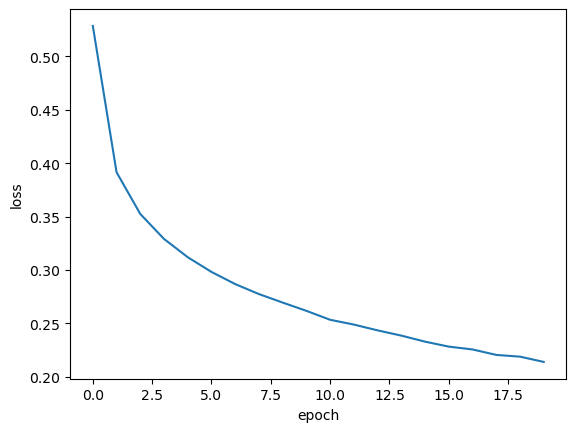

In [115]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

- 에포크를 늘리니 손실이 더 감소한 것은 확인했는데, 과대 적합이 된건 아닌지 검증이 필요

### 검증 손실
- 에포크에 따른 과대적합과 과소적합을 파악하려면 훈련 세트에 대한 점수뿐만 아니라 검증 세트에 대한 점수도 필요
- 이번 장에서는 손실 값을 사용하여 과대/과소 적합을 판단

![alt text](appendix/ch7/image-14.png)

#### 인공 신경망 모델에서 과대/과소 적합 판단을 위한 손실 VS 정확도 
- 인공 신경망 모델이 최적화하는 대상은 정확도가 아니라 손실 함수임
- 따라서 이따금 손실 감소에 비례하여 정확도가 높아지 않는 경우도 있음
- 따라서 모델이 잘 훈련되었는지 판단하려면 정확도보다는 손실 함수의 값을 확인하는 것이 더 나음

In [116]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,validation_data=(val_scaled, val_target))


- 에포크마다 검증 손실을 계산하기 위해 케라스 모델의 `fit()` 메서드에 검증 데이터를 전달할 수 있음
- 다음처럼 validation_data 매개변수에 검증에 사용할 입력과 타깃값을 튜플로 만들어 전달

In [117]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


- 'val_accuracy'는 검증 셋에 대한 정확도, 'val_loss'는 검증 셋에 대한 손실
- 그래프 그려서 확인

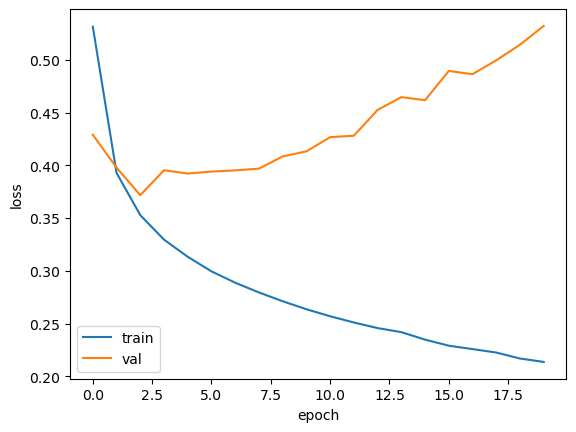

In [119]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

- 약 12 에포크 만에 다시 상승

- 훈련 손실은 꾸준히 감소하기 때문에 전형적인 과대적합 모델이 만들짐 
- 검증 손실이 상승하는 시점을 가능한 뒤로 늦추면 검증 세트에 대한 손실이 줄어들 뿐만 아니라 검증 세트에 대한 정확도도 증가
- 과대적합을 막기 위해 3장에서 배웠던 규제 방식 대신에 신경망에 특화된 규제 방법은 8장에서 참고
- 우선적으로 옵티마이저 하이퍼파라미터를 조정하여 과대적합을 완화
- Adam 옵티마이저를 사용하여 적응적 학습률을 사용하기 때문에 에포크가 진행되면서 학습률의 크기를 조정

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7680 - loss: 0.6736 - val_accuracy: 0.8428 - val_loss: 0.4381
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8536 - loss: 0.4063 - val_accuracy: 0.8557 - val_loss: 0.3957
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8689 - loss: 0.3598 - val_accuracy: 0.8609 - val_loss: 0.3797
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8780 - loss: 0.3305 - val_accuracy: 0.8646 - val_loss: 0.3674
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8865 - loss: 0.3082 - val_accuracy: 0.8691 - val_loss: 0.3534
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8931 - loss: 0.2895 - val_accuracy: 0.8715 - val_loss: 0.3505
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8980 - loss: 0.2752 - val_accuracy: 0.8746 - val_loss: 0.3439
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9029 - loss: 0

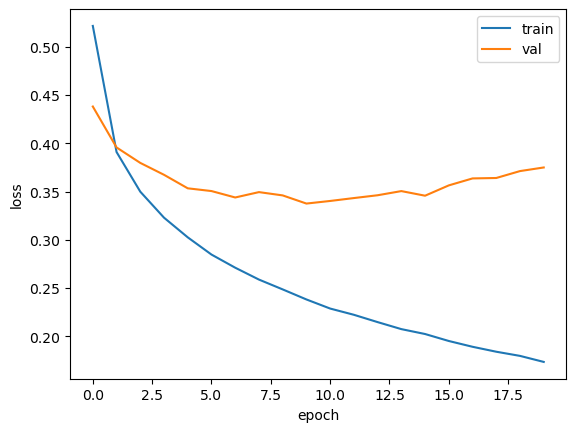

In [120]:
model = model_fn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

- 검증 손실 그래프에 여전히 요동이 남아 있지만 열번째 에포크부터 상승하던 추세는 사라짐
- 더 나은 손실 곡선을 얻으려면 학습률을 조정해서 다시 시도도 가능

### 드롭아웃 Dropout
- 훈련 과정에서 층에 있는 일부 뉴런을 무작위로 꺼서 (뉴런의 출력을 0으로 만듦) 과대적합을 막음

![alt text](appendix/ch7/image-15.png)

- 여기서 얼마나 뉴런을 드롭아웃 할지는 또다른 하이퍼파라미터임
- 이전 층의 일부 뉴런이 랜덤하게 꺼지면 특정 뉴런에 과대하게 의존하는 것을 줄일 수 있고 모든 입력에 대해 주의를 기울여야 함
- 또 그림에서 처럼 드랍아웃을 하이퍼파라미터를 1로 잡아서 그림처럼 두 가지의 신경망을 앙상블 하는 것이라고 볼 수도 있음 
    - 5장에서 보았듯이 앙상블은 과대적합을 막아 주는 좋은 기법입

- 케라스에서는 드롭아웃을 `keras.layers` 패키지 아래 `Dropout` 클래스로 제공
- 어떤 층의 뒤에 드롭아웃을 두어 이 층의 출력을 랜덤하게 0으로 만듦 
- 드롭아웃이 층처럼 사용되지만 훈련되는 모델 파라미터는 없음

In [121]:
# 그럼 앞서 정의한 `model_fn()` 함수에 드롭아웃 객체를 전달하여 층을 추가
# 여기서는 30% 정도를 드롭아웃
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

- 출력 결과에서 볼 수 있듯이 은닉층 뒤에 추가된 드롭아웃 층(Dropout)은 훈련되는 모델 파라미터가 없음
- 또한 입력과 출력의 크기가 같음 
- 일부 뉴런의 출력을 0으로 만들지만 전체 출력 배열의 크기를 바꾸지 않음

- 훈련이 끝난 뒤에 평가나 예측을 수행할 때는 드롭아웃을 적용하지 말아야 하는데, (훈련된 모든 
뉴런을 사용해야 올바른 예측을 수행할 수 있기 때문) 케라스는 모델 평가, 예측 시 드롭아웃을 적용하지 않음

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7324 - loss: 0.7681 - val_accuracy: 0.8441 - val_loss: 0.4287
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8365 - loss: 0.4586 - val_accuracy: 0.8609 - val_loss: 0.3774
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8522 - loss: 0.4091 - val_accuracy: 0.8609 - val_loss: 0.3715
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8588 - loss: 0.3883 - val_accuracy: 0.8682 - val_loss: 0.3592
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8614 - loss: 0.3743 - val_accuracy: 0.8715 - val_loss: 0.3493
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8684 - loss: 0.3609 - val_accuracy: 0.8763 - val_loss: 0.3430
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8698 - loss: 0.3498 - val_accuracy: 0.8764 - val_loss: 0.3353
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8770 - loss: 0

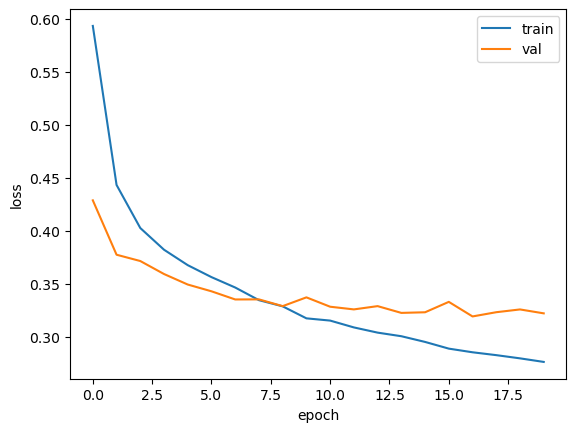

In [122]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


- 열두 번째 에포크 정도에서 검증 손실의 감소가 멈추지만 크게 상승하지 않고 어느 정도 유지됨
- 20번의 에포크 동안 훈련을 했기 때문에 결국 다소 과대적합 되어 있기 때문에 과대적합 되지 않은 모델을 얻기 위해 에포크 횟수를 줄일 필요가 있음 (책에서는 이후 과정에서 에포크 횟수를 11로 지정)

### 모델 저장과 복원
- `save()` : 모델 구조와 파라미터를 함께 저장
    - .keras 확장자 파일에 모두 저장 
- `save_weights()` : 훈련된 모델의 파라미터만 저장
    - HDF5포맷으로 저장하며 .weights.h5 라는 확장자로 끝나야함

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=10, validation_data=(val_scaled, val_target))
model.save('./model/model-whole.keras')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7344 - loss: 0.7639 - val_accuracy: 0.8452 - val_loss: 0.4312
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8365 - loss: 0.4540 - val_accuracy: 0.8562 - val_loss: 0.3896
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8532 - loss: 0.4087 - val_accuracy: 0.8659 - val_loss: 0.3699
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8607 - loss: 0.3871 - val_accuracy: 0.8727 - val_loss: 0.3500
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8664 - loss: 0.3638 - val_accuracy: 0.8717 - val_loss: 0.3511
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8679 - loss: 0.3561 - val_accuracy: 0.8752 - val_loss: 0.3408
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8760 - loss: 0.3434 - val_accuracy: 0.8771 - val_loss: 0.3322
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8759 - loss: 0

In [ ]:
model.save_weights('./model/model.weights.h5')

- 첫 번째는 훈련을 하지 않은 새로운 모델을 만들고 model-weights.h5 
파일에서 훈련된 모델 파라미터를 읽어서 사용
- 두 번째는 아예 model-whole.keras 파일에서 새로운 모델을 만들어 바로 사용

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('./model/model.weights.h5') # 모델 파라미터 불러옴

- `load_weights()` 메서드를 사용하려면 `save_weights()` 메서드로 저장했던 모델과 정확히 같은 구조를 가져야 합니다. 그렇지 않으면 에러가 발생함

- 모델의 검증 정확도를 확인 할 때 케라스에서 예측을 수행하는 `predict()` 메서드를 사용하는데
- 사이킷런과 달리 샘플마다 10개의 클래스에 대한 확률을 반환
    - 지금 실습 데이터가 다중 분류 문제이기 때문 
    - 이진 분류 양성 클래스에 대한 확률 하나만 반환

- 데이터셋에서 덜어낸 검증 세트의 샘플 개수는 12,000개이기 때문에 `predict()` 메서드는 (12000, 10)크기의 배열을 반환

![alt text](appendix/ch7/image-16.png)

- `evaluate()` 메서드를 쓰지 않는 이유는 손실을 계산하기 위해 반드시 먼저 `compile()` 메서드가 선행되어야 하기 때문에 새로운 데이터에 대해 정확도만 계산하면 되는 상황이라면 `predict()`로 충분함

In [126]:
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.8795


- `predict()` 메서드 결과에서 가장 큰 값을 고르기 위해 넘파이 `argmax()` 함수를 사용
- 배열에서 가장 큰 값의 인덱스를 반환

-  `argmax()` 함수의 `axis=-1`은 배열의 마지막 차원을 따라 최댓값을 고름 
- 검증 세트는 2차원 배열이기 때문에 마지막 차원은 1 이 됨
- `axis=1`이면 열을 따라 각 행의 최댓값의 인덱스를 선택하고,`axis=O`이면 행을 따라 각 열의 최댓값의 인덱스를 선택

![alt text](appendix/ch7/image-17.png)

그다음 라인은 `argmax()`로 고른 인덱스(val_labels)와 타깃(val_target)을 비교하여 두 배열에서 각 위치의 값이 같으면 1이되고 다르면 0이 되는데, 이를 평균을 내면 정확도가 됨

In [128]:
model = keras.models.load_model('model-whole.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8838 - loss: 0.3281


[0.3323136866092682, 0.8794999718666077]

- 이전에는 정확도가 0.8795인데 비해 0.8794999718666077로 나왔는데, 같은 모델이 같은 값으로 봐도 무방할 것으로 보임
- `load_model()` 함수는 모델 파라미터뿐만 아니라 모델 구조와 옵티마이저 상태까지 모두 복원하기 때문에 `evaluat()`메서드를 사용이 가능

### 콜백
- 지금까지 20번의 에포크 동안 모델을 훈련하여 검증 손실이 상승하는 지점을 확인 후, 과대적합 되지 않는 에포크만큼 다시 훈련함
- 모델을 두 번씩 훈련하지 않고 한번에 끝내기 위해 콜백 기능을 사용

- 콜백callback : 훈련 과정 중간에 어떤 작업을 수행할 수 있게 하는 객체로 `keras.callbacks` 패키지 아래에 있는 클래스들을 지칭
- `fit()` 메서드의 callbacks 매개변수에 리스트로 전달하여 사용
- `Modelcheckpoint` 콜백은 기본적으로 에포크마다 모델을 저장함
-  `save_best_only=True` 매개변수를 지정하여 가장 낮은 검증 손실을 만드는 모델을 저장할 수 있음

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('./model/best-model.keras',save_best_only=True)

model.fit(train_scaled, train_target, epochs=20, verbose=0,validation_data=(val_scaled, val_target),callbacks=[checkpoint_cb])

- `model_fn()` 함수로 모델을 만들고 `compile()` 메서드를 호출하는 것은 이전과 동일 
- `Modelcheckpoint` 클래스의 객체 `checkpoint_cb`를 만든 후 `fit()` 메서드의 `callbacks` 매개변수에 리스트로 감싸서 전달
- 모델이 훈련한 후에 `best-model.h5`에 최상의 검증 점수를 낸 모델이 저장

In [ ]:
model = keras.models.load_model('./model/best-model.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8847 - loss: 0.3192


[0.32413017749786377, 0.8825833201408386]

- Modelcheckpoint 콜백이 가장 낮은 검증 손실 모델을 자동으로 저장됨
- 검증 점수가 상승하기 시작하면 그 이 후에는 과대적합이 더 커지기 때문에 훈련을 계속할 필요가 없는데, 과대적합이 시작되기 전에 훈련을 미리 중지하는 것을 조기 종료early stopping라고 함.
- 규제 방법 중하나로 볼 수 있으며 EarlyStopping 콜백을 이용

In [ ]:
# 이전 코드에 EarlyStopping 콜백 추가
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('./model/best-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

In [133]:
# 에포크 몇번째에서 멈추었는지 확인
print(early_stopping_cb.stopped_epoch)

13


(결과가 책과 다를 수 있음) -> 
- 에포크 횟수가 0부터 시작하기 때문에 13는 14번째 에포크에서 훈련이 중지되었다는 것을 의미
- `patience=2` 이기 때문에 최상의 모델은 12번째 에포크일 것임

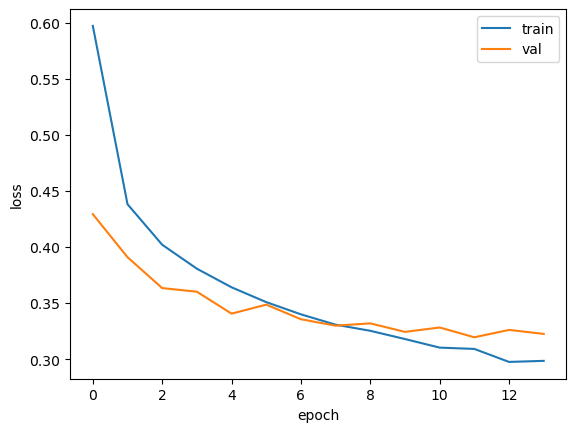

In [135]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [136]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8854 - loss: 0.3181


[0.31949910521507263, 0.8841666579246521]